# House Price Prediction using Linear Regression

### Objective
The objective of this project is to build a Linear Regression model to predict house prices using the California Housing dataset. The model will be evaluated using MAE, MSE, RMSE, and R² Score.

In [23]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [24]:
# Loading Dataset
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [26]:
# Checking Missing Values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [27]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


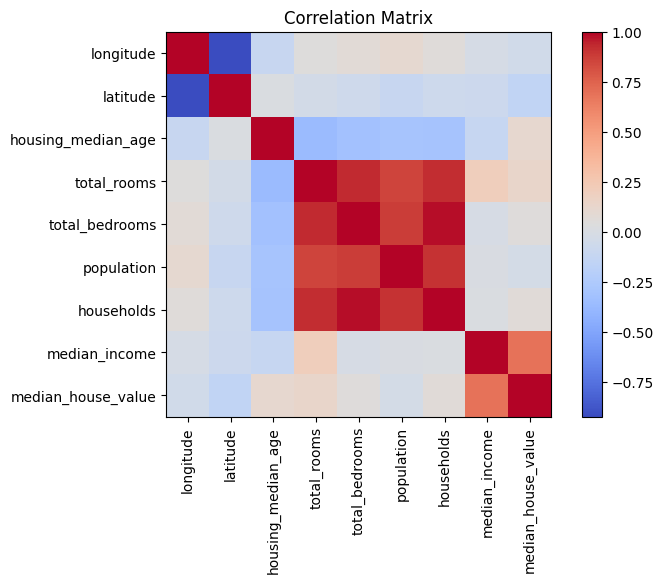

In [28]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,5))
plt.imshow(corr, cmap="coolwarm",interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [29]:
# Handle Missing Values
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [30]:
# Verify
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [31]:
# Features Selection
features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "latitude",
    "longitude"
]

In [32]:
# Create X and Y features
X = df[features]
y = df["median_house_value"] # Target Variable

In [33]:
print(X.head())


   median_income  housing_median_age  total_rooms  latitude  longitude
0         8.3252                41.0        880.0     37.88    -122.23
1         8.3014                21.0       7099.0     37.86    -122.22
2         7.2574                52.0       1467.0     37.85    -122.24
3         5.6431                52.0       1274.0     37.85    -122.25
4         3.8462                52.0       1627.0     37.85    -122.25


In [34]:
print(y.head())

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64


In [35]:
# Train-Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 5)
(4128, 5)
(16512,)
(4128,)


In [37]:
# Create Model
model = LinearRegression()
model


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
# Train the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
# Prediction
y_pred = model.predict(X_test)
y_pred[:10]


array([ 72705.09935449, 175802.98577867, 256526.01739024, 286015.51895527,
       268691.64982554, 205615.66846651, 263835.1135197 , 215108.49364838,
       246851.35902635, 387947.72770273])

In [40]:
# Compare Actual vs Predicted
comparison = pd.DataFrame({
    "Actual Price":y_test.values,
     "Predicted Price": y_pred
})
comparison.head()

,Actual Price,Predicted Price
0,47700.0,72705.099354
1,45800.0,175802.985779
2,500001.0,256526.017390
3,218600.0,286015.518955
4,278000.0,268691.649826


In [41]:
# Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 54230.744476792504
Mean Squared Error (MSE): 5445421137.368428
Root Mean Squared Error (RMSE): 73793.09681378353
R² Score: 0.584448731061169


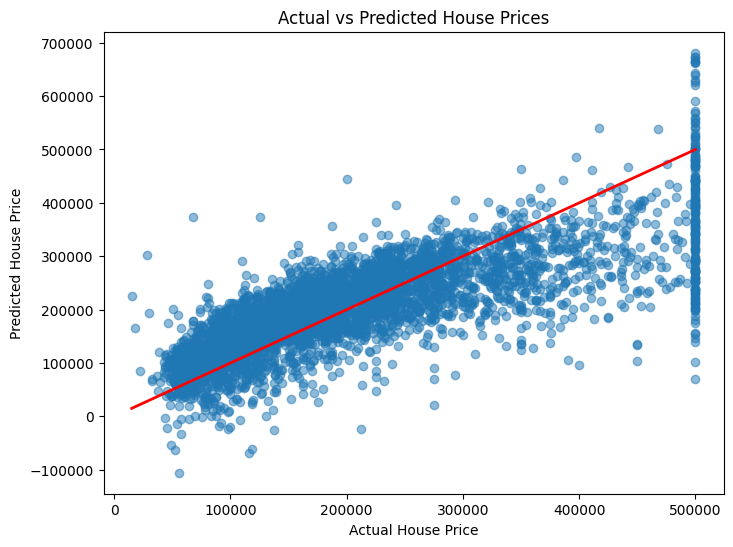

In [42]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Conclusion

In this project, a Linear Regression model was trained to predict house prices using five numerical features from the California Housing dataset.

The model achieved:

- MAE: 54,230.74
- RMSE: 73,793.10
- R² Score: 0.5844

The positive trend in the Actual vs Predicted plot shows that the model learned the relationship between the selected features and house prices. However, prediction errors still exist because only a few features were used and no advanced feature engineering or hyperparameter tuning was performed.

This project demonstrates the complete Linear Regression workflow, including data preprocessing, feature selection, model training, evaluation, and visualization.